# The North Face e-commerce : boosting online sales

In this project, we work with a corpus of 500 item descriptions from The North Face's product catalog. 

The goal is to develop solutions to increase conversion rate:
- deploying a **recommender system** that suggests additional products to users, similar to the items they are already interested in;
- improving the structure of the products catalog thanks to **topic extraction**. The idea is to use unsupervised methods to challenge the existing categories.

This project can be divided into three steps :
1. Identify groups of products that have similar descriptions.
2. Use the groups of similar products to build a simple recommender system algorithm.
3. Use topic modeling algorithms to automatically assess the latent topics present in the item descriptions.

In [1]:
# Import librairies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
import plotly.express as px
from collections import Counter
import contractions
import en_core_web_sm
import wordcloud


# 1. Importing dataset

In [2]:
filename = "data/sample-data.csv"
df = pd.read_csv(filename)

In [3]:
df.head()

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           500 non-null    int64 
 1   description  500 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


In [5]:
print(f"Shape of the dataframe: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"The dataset contains {len(df.loc[df.duplicated()])} duplicates.")

Shape of the dataframe: 500 rows, 2 columns
The dataset contains 0 duplicates.


# 2. Preprocessing

In order to work with text data, we perform text cleaning using `pandas` and `spacy`: 
- we remove the punctuation and special characters, lowercase all characters, 
- remove stop words and lemmatize the documents.

We encode the texts with **TF-IDF transformation** using Scikit learn's `TFIDFVectorizer`.

In [6]:
nlp = en_core_web_sm.load()

In [7]:
def clean_text(text):
    text = re.sub(r'<[^>]+>', " ", text)   # replace HTML tags by normal spaces
    text = contractions.fix(text)          # expand contractions
    text = re.sub(r"[^\w\s]", " ", text)   # remove punctuation
    text = re.sub(r'\s+', ' ', text)       # delete multiple spaces
    text = text.lower()
    return text.strip()

In [8]:
df['description_clean'] = df['description'].apply(clean_text)

In [9]:
## Tokenize the cleaned document
tokenized_doc = df['description_clean'].fillna('').apply(nlp)

# Remove generic stop-words using the predefined list in spaCy
tokenized_doc = tokenized_doc.apply(lambda x: [token.lemma_ for token in x 
                                            if token.text not in STOP_WORDS 
                                            and token.is_alpha
                                            and len(token.text) > 1])

# Add a clean token column 
df["token_clean"] = [" ".join(x) for x in tokenized_doc]

In [10]:
df.head()

,id,description,description_clean,token_clean
0,1,Active classic boxers - There's a reason why o...,active classic boxers there is a reason why ou...,active classic boxer reason boxer cult favorit...
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning up glory re...,active sport boxer brief skin glory require mo...
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no f...,active sport brief superbreathable fly brief m...
3,4,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pants skin in climb ice switch to...,alpine guide pant skin climb ice switch rock t...
4,5,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt on high ridges steep ice and a...,alpine wind jkt high ridge steep ice alpine ja...


### Detecting custom stop words
We are looking for additional words (specific to our corpus) which don't contribute to the meaning of the text. 
Some words are uninformative in our context (clothing description): for instance, "fabric" or "weight" are generally not considered stop words in English, but they may not provide much information for differentiating clothing products and could be potential stop words. 

To build a custom stop word list, we combine different approaches:
- analyzing global frequencies of words (frequencies across the whole descriptions), and focusing on extreme frequencies (high and low);
- looking for words with low IDF, since a low IDF means the term is common (appears in many or all documents) so is less informative;
- creating manually our own list of stopwords. Vocabulary related to sewing or tailoring may be considered as stopwords (for instance, "sew" or "garment").

#### IDF analysis

In [11]:
# Create TF-IDF matrix which describes each word's importance
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['token_clean'])

vocabulary = vectorizer.get_feature_names_out()

# Get IDF scores from each word in the vocabulary
idf_scores = dict(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))

print(f"Number of words in the vocabulary: {len(idf_scores)}") 

# Sort IDF scores by increasing order
idf_sorted = sorted(idf_scores.items(), key=lambda x: x[1])

Number of words in the vocabulary: 3543


In [12]:
# Looking at the first 30 words
for word, idf in idf_sorted[:30]:
    print(f"{word}: {idf:.3f}")

fabric: 1.000
detail: 1.004
oz: 1.016
weight: 1.016
recycle: 1.193
thread: 1.344
common: 1.350
program: 1.350
recyclable: 1.350
soft: 1.652
pocket: 1.668
polyester: 1.691
durable: 1.869
dry: 1.933
seam: 1.970
provide: 1.991
fit: 2.069
water: 2.075
finish: 2.081
cotton: 2.087
lightweight: 2.087
organic: 2.087
nylon: 2.173
spandex: 2.180
dwr: 2.240
repellent: 2.240
zipper: 2.247
usa: 2.275
stretch: 2.282
comfort: 2.319


We want to set a good IDF threshold such that words with IDF below this value are considered too common and likely uninformative.

Given the number of documents ($N=500$) and the IDF formula used in TfidfVectorizer
(
$
\text{IDF}(t) = \log\left( \frac{1 + N}{1 + \text{DF}(t)} \right) + 1
$
):
- $IDF = 1$: the word appears in 74% of the total number of documents;
- $IDF = 1.35$: the word appears in 70% of the total number of documents;
- $IDF = 2$: the word appears in 50% of the total number of documents;
- $IDF = 3$: the word appears in 25% of the total number of documents;

In our case, terms with an IDF below 1.35 seem to be good candidates to be stop words.

In [13]:
# Define a threshold for stop words: words which are included in at least 70% of the documents
idf_threshold = 1.351
stopwords_lowidf = [word for word, idf in idf_scores.items() if idf <= idf_threshold]
stopwords_lowidf = set(stopwords_lowidf)
stopwords_lowidf

{'common',
 'detail',
 'fabric',
 'oz',
 'program',
 'recyclable',
 'recycle',
 'thread',
 'weight'}

#### Word global frequency analysis

In [14]:
text_all = " ".join(df["token_clean"].dropna().astype(str))
words = text_all.split()
freq_counter = Counter(words)
df_freq = pd.DataFrame(freq_counter.items(), columns=["term", "frequency"]).reset_index(drop=True)
df_freq["relative_frequency (%)"] = 100*df_freq["frequency"] / df_freq["frequency"].sum()

In [15]:
# High global frequency words (top 100)
df_freq.sort_values(by="frequency", ascending=False).round(2).head(100)

,term,frequency,relative_frequency (%)
31,oz,1147,2.21
42,recycle,1119,2.16
47,fabric,1000,1.93
150,pocket,844,1.63
33,polyester,708,1.37
...,...,...,...
653,ink,107,0.21
74,leg,107,0.21
343,flap,107,0.21
341,fleece,106,0.20


In [16]:
# Words with low global frequency
df_freq.sort_values(by="frequency", ascending=True).round(2).head(100)

,term,frequency,relative_frequency (%)
3514,ondrus,1,0.0
3515,jasper,1,0.0
3516,national,1,0.0
3534,tasteful,1,0.0
3502,roy,1,0.0
...,...,...,...
3451,explore,1,0.0
2188,icy,1,0.0
2189,hibernation,1,0.0
2105,cyclist,1,0.0


In [17]:
words_only_once = df_freq[df_freq["frequency"] == 1]["term"].tolist()

print(f"Number of words which appear only once in the description: {len(words_only_once)}")
print(words_only_once[:50])

Number of words which appear only once in the description: 1340
['reason', 'especially', 'decide', 'poach', 'superbreathable', 'octane', 'edging', 'opacity', 'setting', 'ascensionist', 'strike', 'stitchless', 'fabic', 'decrease', 'heavenly', 'application', 'coordinate', 'horizon', 'raindrop', 'young', 'jawline', 'colorway', 'neutralize', 'underneath', 'refresh', 'june', 'navajo', 'starry', 'date', 'proficient', 'cringe', 'unnamed', 'thrashy', 'chimney', 'language', 'shrug', 'gift', 'chance', 'energetic', 'cooling', 'accessibility', 'f', 'linear', 'noggin', 'boiling', 'transient', 'overheat', 'achieve', 'harmonic', 'slacker']


In [18]:
# Words with a frequency higher than 1000 are likely to be stop words. This list overlaps with the one created with the IDF approach.
stopwords_highfreq = df_freq[df_freq["frequency"] >= 1000]["term"].tolist()
stopwords_highfreq = set(stopwords_highfreq)
print(f"Frequent words (frequency >= 1000): {stopwords_highfreq}")

Frequent words (frequency >= 1000): {'oz', 'recycle', 'fabric'}


In [19]:
# We add words with a very low frequency (those which appear once in the whole description) to the list of stopwords
stopwords_lowfreq = df_freq[df_freq["frequency"] == 1]["term"].tolist()
stopwords_lowfreq = set(stopwords_lowfreq)

In [20]:
# We add vocabulary specific to sewing and tailoring
stopwords_sewing = ["adjustment",
                    "bias", "binding",
                    "clothe", "clothing", "construction", "cut", 
                    "dart", "denier", 
                    "garment",
                    "hem", "hemline",
                    "fit", "fly", 
                    "inseam", "seam", "button",
                    "lining",
                    "notch", 
                    "panel",  "placket", "pleat",
                    "sew", "size", "stitch",
                    "weave", "woven"
                    ]

In [21]:
custom_stopwords = set(stopwords_lowidf)
custom_stopwords.update(stopwords_highfreq)
custom_stopwords.update(stopwords_lowfreq)
custom_stopwords.update(stopwords_sewing)
print(f"Number of custom stopwords: {len(custom_stopwords)}")
print(f"Custom stopwords: {custom_stopwords}")

Number of custom stopwords: 1376
Custom stopwords: {'skive', 'humorous', 'mantle', 'sustainability', 'fluttery', 'exposure', 'bed', 'annoyingly', 'whimsy', 'foundation', 'al', 'decide', 'dicey', 'cleat', 'button', 'three', 'fullness', 'headache', 'bead', 'flatiron', 'weary', 'midday', 'supremely', 'neatly', 'panty', 'yvon', 'crow', 'broadly', 'shoshoni', 'immortal', 'despite', 'enliven', 'gleeful', 'knock', 'singular', 'sonnie', 'professional', 'bone', 'onshore', 'nerve', 'snowmelt', 'knot', 'recovery', 'longboarde', 'terrestrial', 'warmer', 'sweep', 'appropriate', 'marco', 'flop', 'irritable', 'fire', 'depend', 'creekside', 'dentr', 'cramped', 'iv', 'rule', 'confab', 'feather', 'inconspicuous', 'authority', 'shafer', 'andrew', 'spruce', 'insert', 'examine', 'romantic', 'skill', 'abroad', 'talus', 'blossom', 'question', 'linear', 'pedal', 'carefully', 'geek', 'overlocked', 'circuit', 'pure', 'bite', 'byproduct', 'interfere', 'museum', 'honor', 'mercy', 'sprint', 'splitter', 'cranium', 

In [22]:
# Updating the final stopwords list
final_stopwords = set(STOP_WORDS)
final_stopwords.update(custom_stopwords)

In [23]:
# Tokenisation using the final stopwords

del tokenized_doc
del df['token_clean']

tokenized_doc = df['description_clean'].fillna('').apply(lambda x: nlp(x))

# Remove stop-words
tokenized_doc = tokenized_doc.apply(lambda x: [token.lemma_ for token in x 
                                            if token.lemma_.lower() not in final_stopwords 
                                            and token.is_alpha
                                            and len(token.text) > 1])

# Add a clean token column 
df["token_clean"] = [" ".join(x) for x in tokenized_doc]

In [24]:
df.head(10)

,id,description,description_clean,token_clean
0,1,Active classic boxers - There's a reason why o...,active classic boxers there is a reason why ou...,active classic boxer boxer cult favorite cool ...
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning up glory re...,active sport boxer brief skin glory require mo...
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no f...,active sport brief brief minimalist choice hig...
3,4,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pants skin in climb ice switch to...,alpine guide pant skin climb ice switch rock t...
4,5,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt on high ridges steep ice and a...,alpine wind jkt high ridge steep ice alpine ja...
5,6,Ascensionist jkt - Our most technical soft she...,ascensionist jkt our most technical soft she w...,jkt technical soft mountain pursuit alpinist b...
6,7,"Atom - A multitasker's cloud nine, the Atom pl...",atom a multitasker s cloud nine the atom plays...,atom multitasker cloud atom play courier bag d...
7,8,Print banded betina btm - Our fullest coverage...,print banded betina btm our fullest coverage b...,print band betina btm coverage betina highest ...
8,9,Baby micro d-luxe cardigan - Micro D-Luxe is a...,baby micro d luxe cardigan micro d luxe is a h...,baby micro luxe cardigan micro luxe soft earth...
9,10,Baby sun bucket hat - This hat goes on when th...,baby sun bucket hat this hat goes on when the ...,baby sun bucket hat hat sun rise stay start fa...


In [25]:
# Create TF-IDF matrix which describes each word's importance
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(df['token_clean'])
vocabulary = vectorizer.get_feature_names_out()
print(f"Type and shape of tfidf: {type(tfidf), tfidf.shape}")

Type and shape of tfidf: (<class 'scipy.sparse._csr.csr_matrix'>, (500, 2145))


# 3. Clustering: defining groups of products with similar descriptions

We train a **clustering model** that will create groups of products for which the descriptions are "close" to each other. 

We use `DBSCAN` to make some clustering on the TF-IDF matrix. When dealing with texts, the distance metric to be used is "cosine" instead of "euclidean". We look for best values for hyperparameters that allow to get 10-20 clusters and not too many outliers:
- `eps` (maximum distance which determines whether an observation belongs to a *core sample* or not)
- `min_samples` (minimum number of observations to create a *core sample*).  

We compute the silhouette score to measure the quality of the clustering (how similar an observation is to its own cluster compared to other clusters).

We display a **wordcloud** for each cluster to analyze the results and see if the groups contain different words.

In [26]:
# Loop which iterates over a range of values for eps and min_samples

results = []

eps_values = np.arange(0.3, 0.8, 0.1)
min_samples_values = range(5, 12, 1)

for eps in eps_values:
    
    for min_samples in min_samples_values:
        
        # Instanciate DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine", algorithm="brute")
        
        # Fit on normalized data
        db.fit(tfidf)
        
        # Obtain the predicted labels
        labels = db.labels_
        
        # Number of clusters created, without the cluster containing noise/outliers
        nb_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # Number and percentage of observations in the cluster containing outliers (label equal to -1)
        nb_outliers = np.sum(labels == -1)
        prct_outliers = nb_outliers/len(labels)*100
        
        # Select clusters which are not outliers (label different from -1)
        mask = labels != -1
        tfidf_filtered = tfidf[mask]
        labels_not_noise = labels[mask]

        # Compute silhouette score on clusters which are not noise
        if nb_clusters >= 2:
            score = silhouette_score(tfidf_filtered, labels_not_noise, metric='cosine')
        else:
            score = -2
        
        results.append({
            'eps' : eps,
            'min_samples' : min_samples,
            'nb_clusters' : nb_clusters,
            'nb_outliers' : nb_outliers,
            'prct_outliers' : prct_outliers,
            'silhouette_score' : score
            })

In [27]:
# Results
df_results = pd.DataFrame(results).round(2)
df_results.loc[(df_results["nb_clusters"]>=10) & (df_results["nb_clusters"]<=20)].sort_values(["prct_outliers", "silhouette_score"], ascending=[True, False])

,eps,min_samples,nb_clusters,nb_outliers,prct_outliers,silhouette_score
28,0.7,5,12,64,12.8,0.14
29,0.7,6,13,76,15.2,0.14
30,0.7,7,10,105,21.0,0.15
31,0.7,8,12,121,24.2,0.17
22,0.6,6,17,256,51.2,0.37
23,0.6,7,14,280,56.0,0.38
24,0.6,8,11,307,61.4,0.37
14,0.5,5,14,333,66.6,0.47
7,0.4,5,13,398,79.6,0.55


In [28]:
df_count_cluster = df_results.pivot(index='eps', columns='min_samples', values='nb_clusters')
df_count_cluster.index = df_count_cluster.index.astype(str)
df_count_cluster.columns = df_count_cluster.columns.astype(str)
df_count_cluster.head()

min_samples,5,6,7,8,9,10,11
eps,,,,,,,
0.3,7,6,2,2,1,1,1
0.4,13,9,8,3,2,1,1
0.5,14,9,7,5,5,4,3
0.6,23,17,14,11,7,6,5
0.7,12,13,10,12,9,7,6


In [29]:
df_outliers = df_results.pivot(index='eps', columns='min_samples', values='prct_outliers')
df_outliers.index = df_outliers.index.astype(str)
df_outliers.columns = df_outliers.columns.astype(str)
df_outliers.head()

min_samples,5,6,7,8,9,10,11
eps,,,,,,,
0.3,89.6,90.6,95.4,95.4,97.0,97.0,97.0
0.4,79.6,84.0,85.6,93.2,95.2,97.0,97.0
0.5,66.6,71.8,74.2,77.2,79.8,82.8,85.6
0.6,41.8,51.2,56.0,61.4,69.4,71.6,74.0
0.7,12.8,15.2,21.0,24.2,30.2,37.8,40.6


In [30]:
df_silhouette = df_results.pivot(index='eps', columns='min_samples', values='silhouette_score')
df_silhouette.index = df_silhouette.index.astype(str)
df_silhouette.columns = df_silhouette.columns.astype(str)
df_silhouette.head()

min_samples,5,6,7,8,9,10,11
eps,,,,,,,
0.3,0.75,0.78,0.78,0.78,-2.00,-2.00,-2.00
0.4,0.55,0.56,0.56,0.69,0.68,-2.00,-2.00
0.5,0.47,0.46,0.44,0.44,0.41,0.47,0.49
0.6,0.34,0.37,0.38,0.37,0.38,0.38,0.39
0.7,0.14,0.14,0.15,0.17,0.17,0.17,0.18


In [31]:
fig = px.imshow(df_count_cluster, text_auto=True)
fig.update_layout(
    height=450, 
    width=700,
    xaxis_title="min_samples",
    yaxis_title="eps",
    title=dict(
            text="Number of clusters (excluding noise) for different values of eps et min_samples",
            x=0.5,
            xanchor='center'
        )
)

fig.show()

fig = px.imshow(df_outliers, text_auto=True)
fig.update_layout(
    height=450, 
    width=700,
    xaxis_title="min_samples",
    yaxis_title="eps",
    title=dict(
            text="Pourcentage of outliers for different values of eps et min_samples (%)",
            x=0.5,
            xanchor='center'
        )
)

fig.show()

fig = px.imshow(df_silhouette, text_auto=True)
fig.update_layout(
    height=450, 
    width=700,
    xaxis_title="min_samples",
    yaxis_title="eps",
    title=dict(
            text="Silhouette score for different values of eps et min_samples",
            x=0.5,
            xanchor='center'
        )
)

fig.show()

Looking at the percentages of outliers, we check that, as expected:
- Lower *eps* means that the maximum distance between two observations for them to be considered neighbors is reduced. As the threshold is more restrictive, more observations are marked as outliers.
- Lower *min samples* means that the minimum number of points required to form a core point is reduced. Less observations are needed to create a cluster, so less observations are marked as outliers.

There is an inverse relationship between the silhouette score and the proportion of outliers.
Higher values of silhouette score are associated with lower values of *eps*, so with higher number of outliers. There is a trade-off between these two criteria.

Within the ranges of *eps* and *min_samples* we tested, the combination that gives a number of clusters between 10 and 20 and also the less number of outliers is : 
**eps = 0.7** and **min_samples = 5**. 
With this combination, 12 clusters are identified and the proportion of outliers is 12.8%. We note that the silhouette score is deceptive (0.14).


In [32]:
# Fit the best model
db = DBSCAN(eps=0.7, min_samples=5, metric="cosine", algorithm="brute")
db.fit(tfidf)

# Obtain the predicted labels
labels = db.labels_
        
# Number of clusters created, without the cluster containing noise
nb_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Select clusters which are not noise (label different from -1)
mask = labels != -1
tfidf_filtered = tfidf[mask]
labels_not_noise = labels[mask]

# Compute silhouette score on clusters which are not noise
score = silhouette_score(tfidf_filtered, labels_not_noise, metric='cosine')
print(f"Silhouette score (without noise) : {score:.3f}")

Silhouette score (without noise) : 0.138


In [33]:
# Add a new column "cluster" to the dataframe
df["cluster"] = labels
df.head(5)

,id,description,description_clean,token_clean,cluster
0,1,Active classic boxers - There's a reason why o...,active classic boxers there is a reason why ou...,active classic boxer boxer cult favorite cool ...,0
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning up glory re...,active sport boxer brief skin glory require mo...,0
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no f...,active sport brief brief minimalist choice hig...,0
3,4,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pants skin in climb ice switch to...,alpine guide pant skin climb ice switch rock t...,1
4,5,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt on high ridges steep ice and a...,alpine wind jkt high ridge steep ice alpine ja...,1


In [34]:
# Display number of IDs within each cluster
df_len_cluster = df['cluster'].value_counts().reset_index()
df_len_cluster['prct'] = round(df_len_cluster['count']/df_len_cluster['count'].sum() * 100, 2)
df_len_cluster = df_len_cluster.sort_values('cluster', ignore_index=True)
df_len_cluster

,cluster,count,prct
0,-1,64,12.8
1,0,64,12.8
2,1,186,37.2
3,2,30,6.0
4,3,9,1.8
5,4,9,1.8
6,5,77,15.4
7,6,8,1.6
8,7,6,1.2
9,8,24,4.8


In [35]:
fig = px.bar(df_len_cluster, 
            x='cluster', 
            y='prct', 
            title="Proportion of products by cluster",
            labels={'cluster': 'Cluster', 'prct': 'Proportion (%)'},
            text='prct'
            )
fig.add_annotation(
    x=0, y=-0.3,
    xanchor="left",  
    text="NB: cluster -1 corresponds to outliers", 
    showarrow=False, 
    xref="paper", yref="paper",
    font=dict(size=11)
)
fig.update_traces(
            texttemplate='%{text}%', 
            textposition='auto',
            textfont_size=11
            )
fig.update_layout(
    xaxis=dict(
        dtick=1
    ),
    title_x=0.5,
)
fig.show()

Clusters are of varying sizes.   
Besides the outlier cluster (13% of products), there is:
- one large cluster with more than 1/3 of products, which may be heterogeneous;
- 3 intermediate clusters with between 12–15% of products;
- 2 small clusters (with around 5–6% of products)
- 4 very small clusters (less than 2% of products). 

### Wordclouds of clusters

Cluster 0


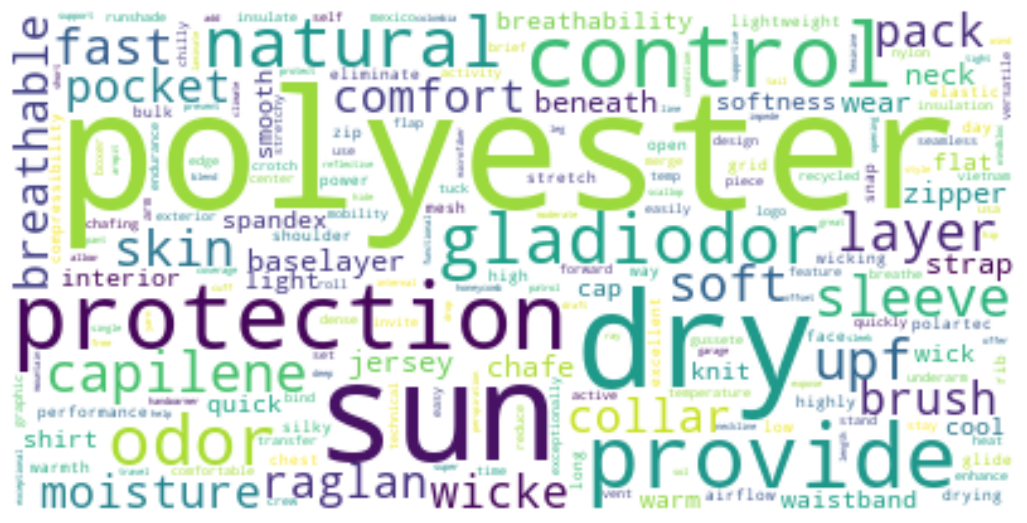

Cluster 1


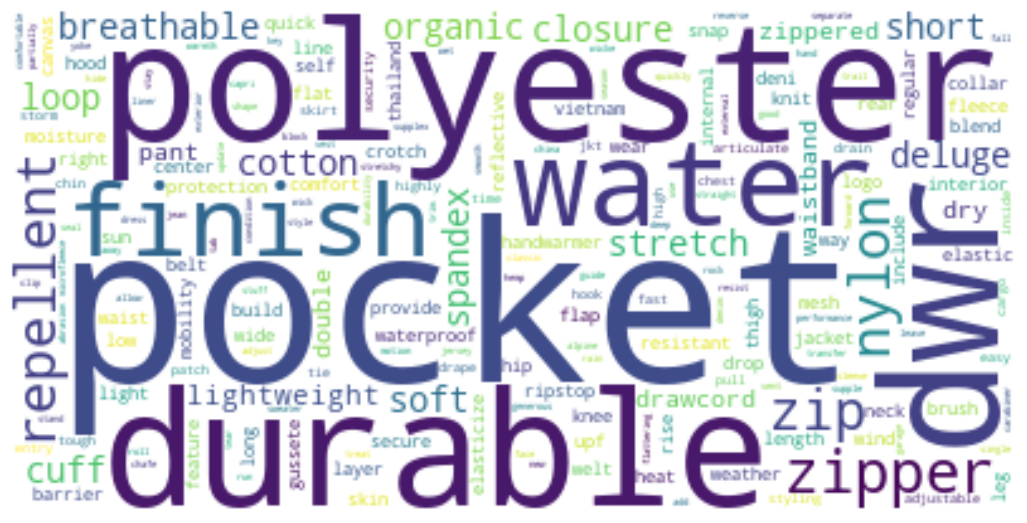

Cluster 2


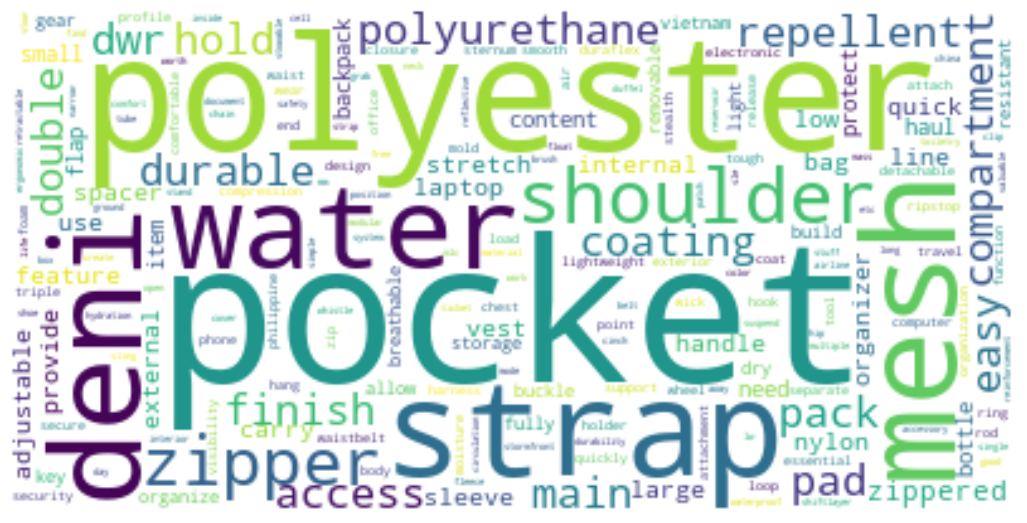

Cluster 3


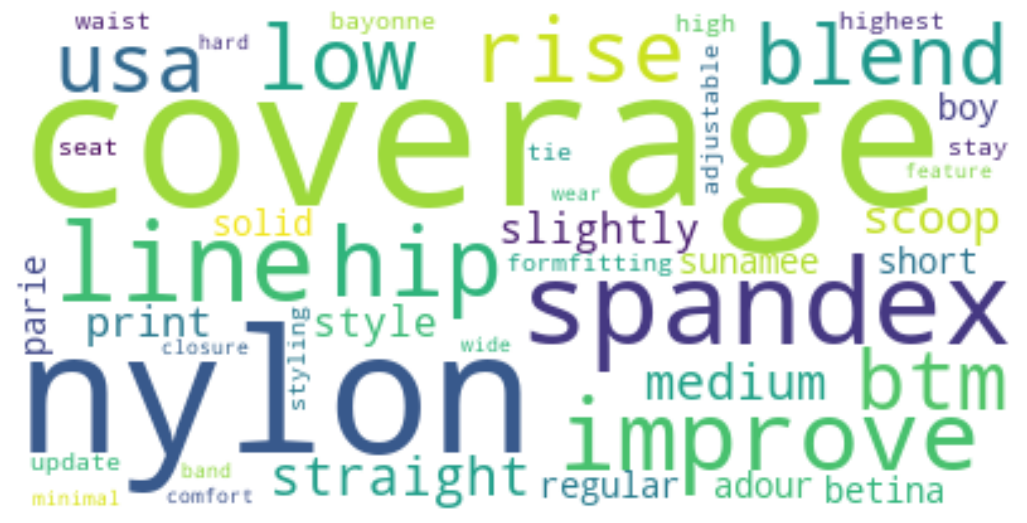

Cluster 4


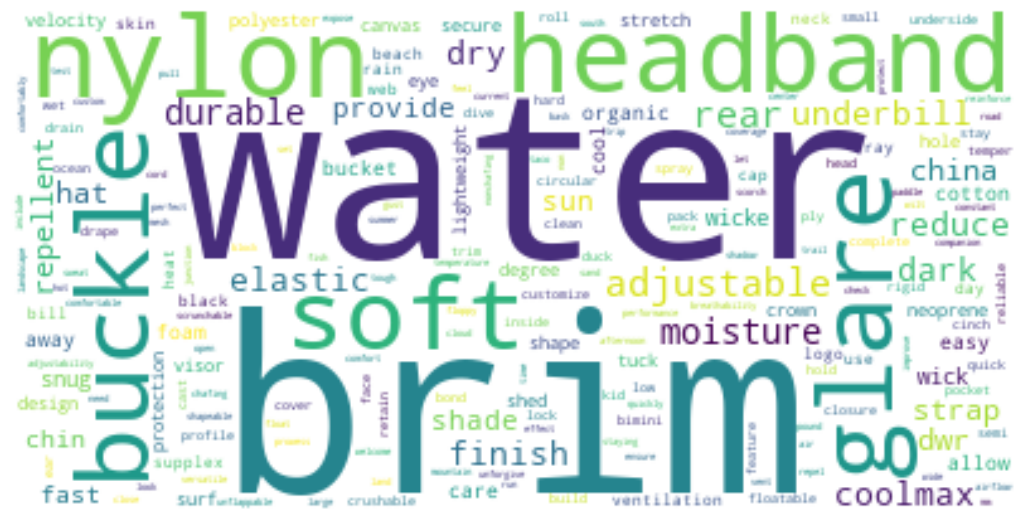

Cluster 5


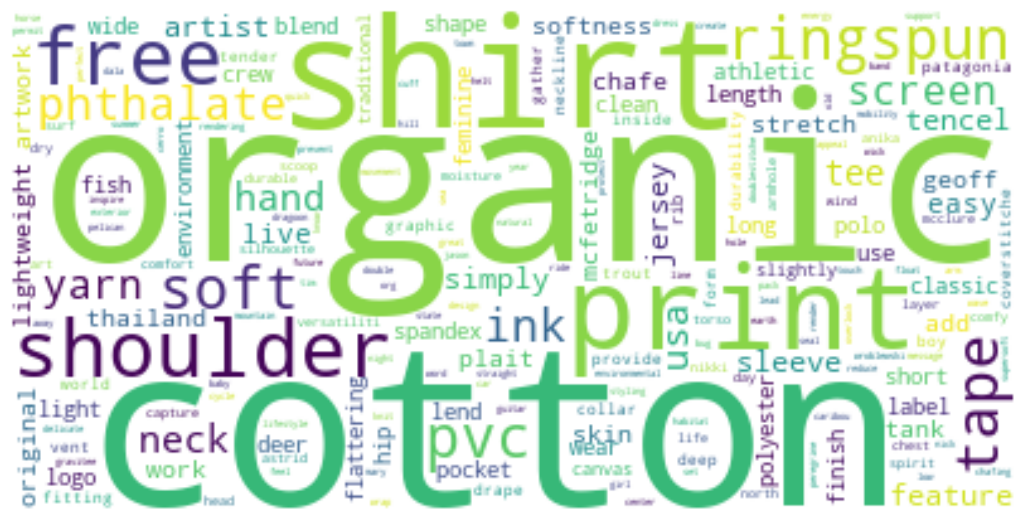

Cluster 6


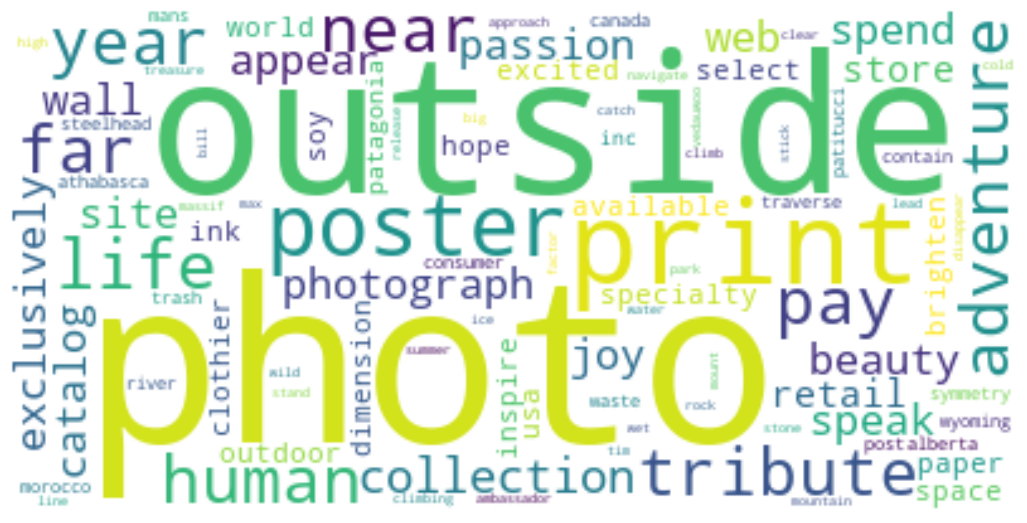

Cluster 7


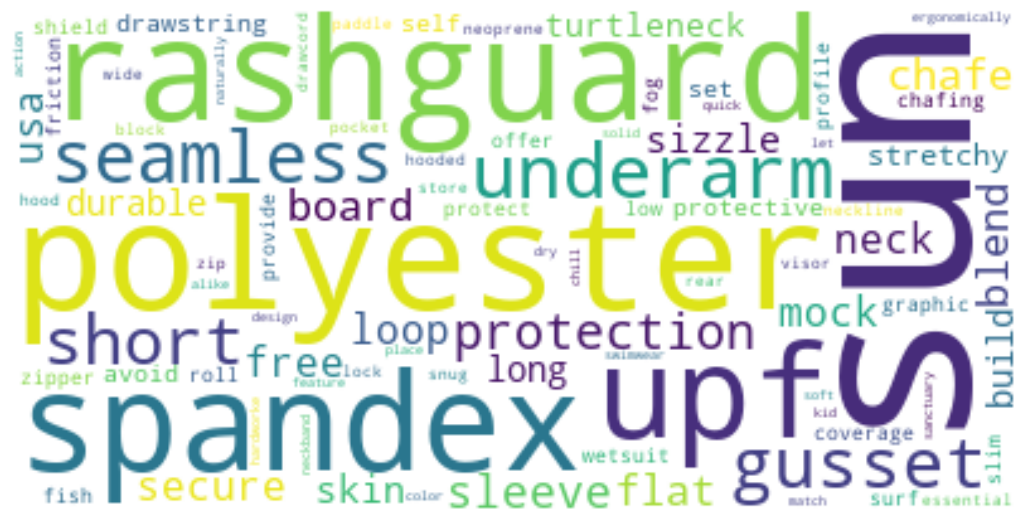

Cluster 8


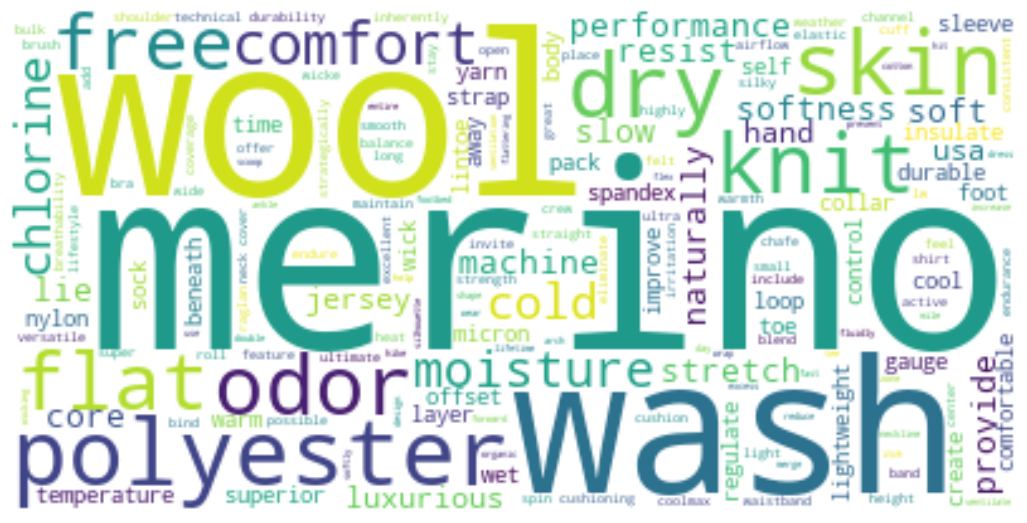

Cluster 9


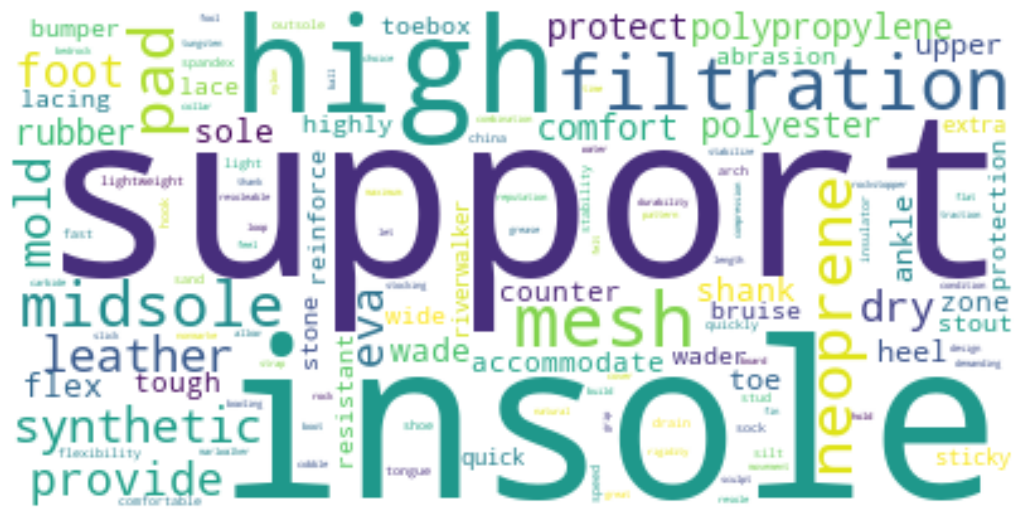

Cluster 10


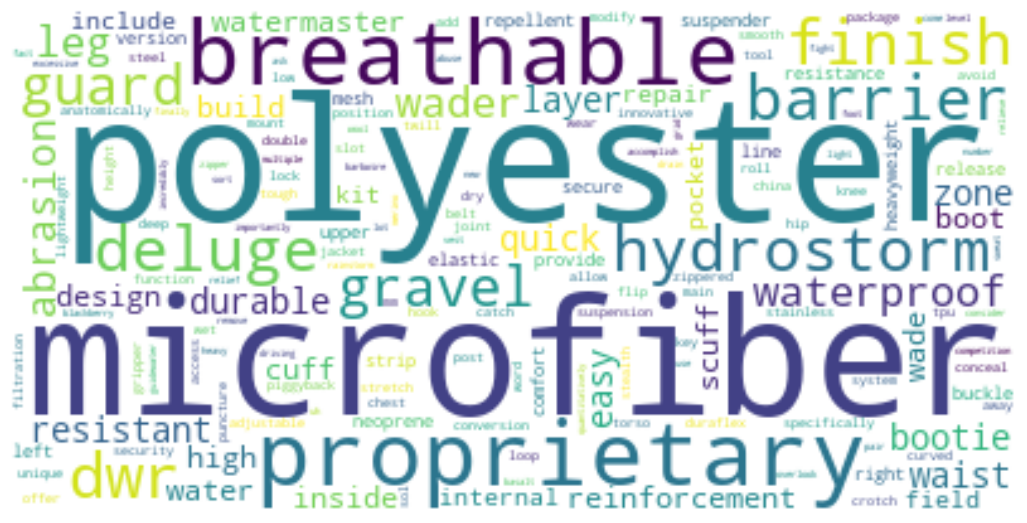

Cluster 11


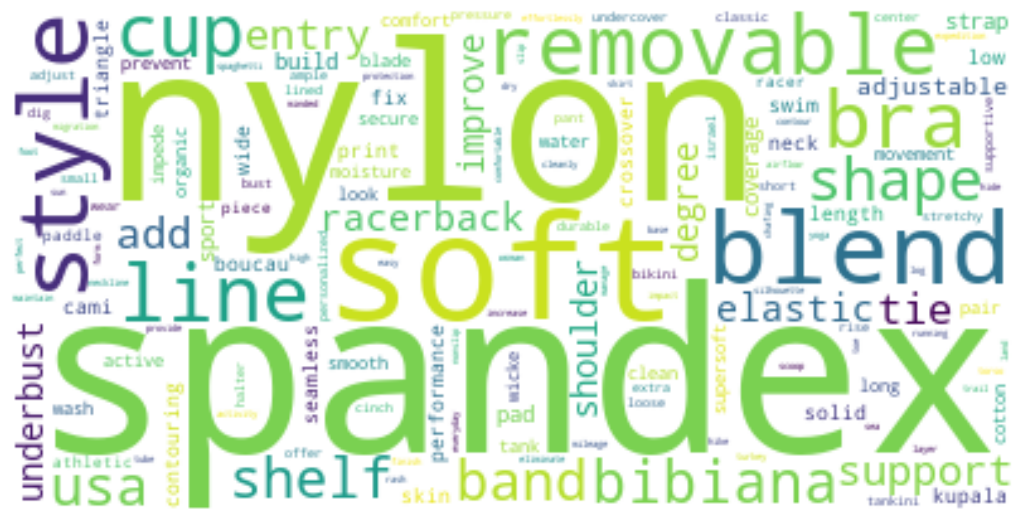

In [36]:
# Aggregate texts for each cluster
texts_by_cluster = df.groupby('cluster', dropna=False)['token_clean'].apply(lambda x: ' '.join(x))

# Instanciate wordcloud
wd = wordcloud.WordCloud(background_color="white", collocations=False)

# Generate wordclouds for clusters different from outliers' cluster
for cluster_id, text in texts_by_cluster.items():
    if cluster_id != -1:
        print(f"Cluster {cluster_id}")
        cloud = wd.generate(text)
        plt.figure(figsize = (13, 10))
        plt.imshow(cloud, interpolation="bilinear")
        plt.axis("off")
        plt.show()

Clusters are not very clearly separated, which is not very surprising because of the shared vocabulary used in product descriptions. In the wordclouds, some words appear in multiple clusters (for example, polyester appears in half of them). However semantic logic can be found in this clustering. 
For instance: 
- cluster 0 groups technical products designed to manage moisture and odors;
- cluster 5 contains products comfortable to wear and made with natural materials (ex: organic cotton);
- cluster 8 groups merino wool products.

# 4. Recommender system

We use the cluster IDs from the previous section to build a recommender system. The aim is to be able to suggest to a user some products that are similar to the ones she/he is interested in. To do this, we will consider that products belonging to the same cluster are similar.

We create a function named `find_similar_items` which takes an argument `item_id` representing the ID of a product, and which returns a list of 5 item IDs that belong to the same cluster as the product passed in argument.

Then we use python's `input()` function to allow the user to choose a product and perform some suggestions of similar items.

In [37]:
def clean_html(text):
    # Removes all HMTL tags from text
    clean_text = re.sub(r'<.*?>', '', text)
    return clean_text

In [38]:
def find_similar_items(item_id, n=5):

    if item_id not in df["id"].values:
        print("This ID is unknown. Please enter a number between 1 and 500.")
        return
        
    else:
        # identify cluster associated with the item id
        cluster = df.loc[df['id'] == item_id, 'cluster'].values[0]
        
        # if the item belongs to the outliers cluster
        if cluster == -1:
            print("Unfortunately we have no suggestion of similar items. Please retry with another ID.")
        
        else:
            # identify all products which belong to the same cluster, except the item id the user has entered
            df_similar = df.loc[(df['cluster'] == cluster) & (df['id'] != item_id)]
            
            # retrieve a sample of n similar products at maximum
            df_similar = df_similar.sample(min(n, len(df_similar)))

            # clean the descriptions to remove HTML tags using the clean_html function
            df_similar['description'] = df_similar['description'].apply(clean_html)
            
            # create lists of similar IDs and similar ID names
            similar_id = df_similar['id'].tolist()
            similar_description = df_similar['description'].tolist()
        
            recommandation = "\n".join(f"ID {id}: {name}" for id, name in zip(similar_id, similar_description))

    return recommandation

In [39]:
try:
    user_input = int(input("Please enter a product ID:"))
    recommandation = find_similar_items(user_input)
    
    if recommandation:
        print(f"You may be interested in the following products, related with product ID #{user_input}:\n{recommandation}")
        
except ValueError:
    print("This ID is not valid. Please enter a number between 1 and 500.")

You may be interested in the following products, related with product ID #1:
ID 60: Cap 1 graphic tee - Kids live at full throttle. Allow their boundless energy to flourish with the short-sleeved Capilene 1 Graphic Tee, which keeps them dry by wicking away moisture and cool with a silky 3.7-oz 100% all-recycled polyester fabric. A built-in 15-UPF sun protection protects their skin, while Gladiodor natural odor control keeps them huggable. Raglan sleeves allow shoulders to move naturally; the ribbed collar feels smooth against skin. Three fun graphics reside on the front. Recyclable through the Common Threads Recycling Program.Details: "This lightweight, silky and fast-wicking Capilene 1 tee is our coolest wearing baselayer, with Gladiodor natural odor control" Built-in 15-UPF sun protection Ribbed collar for on/off easily Raglan sleeves without underarm panels Fun graphicsFabric: 3.7-oz 100% all-recycled polyester with Gladiodor natural odor control and 15-UPF sun protection. Recyclabl

# 5. Topic modeling

The aim is to use an **LSA (Latent Semantic Analysis) model** to automatically **extract latent topics in the products' descriptions**.

- We use TruncatedSVD to make some topic extraction from the TF-IDF matrix. We choose `n_components` between 10 and 20 topics. Then we save the encoded matrix into a variable named `topic_encoded_df`.
- Contrary to clustering, LSA allows to map each document to a mixing of several topics. For this reason, it's a bit more difficult to interpret the topics as categories: one document can actually be related to several topics at a time. To make things easier, we extract the main topic of each document.
- We display `wordclouds` to analyze the results.

In [40]:
# Estimate a LSA model with a high number of components and display the explained variance
n_components = 100
svd_model = TruncatedSVD(n_components=n_components, n_iter=100, random_state=0)
lsa = svd_model.fit_transform(tfidf)
explained_variance = svd_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Dataframe with number of components and cumulative variance
df_cumulative_variance = pd.DataFrame({
    'Components': np.arange(1, n_components + 1),
    'Cumulative variance': cumulative_variance
})

fig = px.line(df_cumulative_variance, 
            x='Components', 
            y='Cumulative variance',
            markers=True)

fig.update_layout(
    height=400,
    width=800,
    xaxis_title='Number of topics',
    yaxis_title='Cumulative explained variance',
    title=dict(
        text="Cumulative explicated variance",
        x=0.5,
        xanchor='center'
    )
)

fig.show()


In [41]:
# Define a number of topics between 10 and 20
# We choose n=10, this ensures that each main topic is related to a minimum of 5 products
# 10 components explain 21% of the variance

n_components = 10

# Define and fit the model
svd_model = TruncatedSVD(n_components=n_components, n_iter=100, random_state=0)
lsa = svd_model.fit_transform(tfidf)

# Documents-topics matrix
topic_encoded_df = pd.DataFrame(lsa, columns = [f"topic_{i}" for i in range(1, n_components+1)])
print("Documents-topics matrix (5 first rows):")
display(topic_encoded_df.head().round(2))

# Topics-terms matrix
topic_term_df = pd.DataFrame(svd_model.components_, index = [f"topic_{i}" for i in range(1, n_components+1)])
print("Topics-terms matrix:")
display(topic_term_df.head().round(2))


Documents-topics matrix (5 first rows):


,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10
0,0.17,-0.05,0.20,0.01,-0.11,-0.02,-0.03,-0.00,-0.12,-0.06
1,0.23,-0.05,0.14,0.03,-0.04,0.13,0.07,-0.03,-0.09,-0.09
2,0.24,-0.09,0.12,0.01,-0.03,0.12,0.16,0.04,-0.05,-0.05
3,0.41,-0.25,-0.14,-0.14,0.06,0.00,-0.03,-0.15,-0.08,-0.07
4,0.40,-0.24,-0.06,-0.22,-0.00,-0.06,0.05,-0.05,0.03,0.01


Topics-terms matrix:


,0,1,2,3,4,5,6,7,8,9,...,2135,2136,2137,2138,2139,2140,2141,2142,2143,2144
topic_1,0.00,0.02,0.0,0.0,0.01,0.00,0.03,0.01,0.01,0.0,...,0.0,0.01,0.02,0.00,0.10,0.13,0.07,0.0,0.02,0.01
topic_2,-0.00,-0.02,-0.0,-0.0,-0.00,0.00,-0.02,-0.00,-0.01,-0.0,...,-0.0,-0.00,-0.00,0.01,-0.05,-0.10,-0.06,-0.0,-0.02,-0.01
topic_3,0.01,-0.02,-0.0,-0.0,-0.00,0.00,-0.02,-0.00,0.00,-0.0,...,-0.0,0.00,-0.00,-0.00,-0.06,-0.07,-0.06,-0.0,-0.02,-0.00
topic_4,-0.00,-0.01,-0.0,-0.0,0.00,0.01,-0.03,-0.01,0.00,-0.0,...,-0.0,0.01,0.04,-0.01,0.10,-0.11,-0.05,-0.0,-0.02,-0.01
topic_5,-0.01,0.01,0.0,-0.0,0.00,0.00,0.01,0.00,0.00,0.0,...,0.0,0.00,-0.00,0.00,-0.02,-0.00,0.02,0.0,0.00,0.02


In [42]:
# Extract the main topic of each document
df['main_topic'] = np.argmax(topic_encoded_df, axis=1)+1
df.head()

,id,description,description_clean,token_clean,cluster,main_topic
0,1,Active classic boxers - There's a reason why o...,active classic boxers there is a reason why ou...,active classic boxer boxer cult favorite cool ...,0,3
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning up glory re...,active sport boxer brief skin glory require mo...,0,1
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no f...,active sport brief brief minimalist choice hig...,0,1
3,4,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pants skin in climb ice switch to...,alpine guide pant skin climb ice switch rock t...,1,1
4,5,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt on high ridges steep ice and a...,alpine wind jkt high ridge steep ice alpine ja...,1,1


In [43]:
# Combine dataframe of products' description with the documents-topic dataframe
df = pd.concat([df, topic_encoded_df], axis=1)

In [44]:
# Save the enriched dataframe
cols_to_keep = ['id', 'description', 'cluster', 'main_topic'] +  [f'topic_{i}' for i in range(1, 11)]
df[cols_to_keep].to_csv("exports/sample-data-augmented.csv", index=False)

In [45]:
# Products' repartition by main_topic
topic_count = df['main_topic'].value_counts().reset_index()
topic_count['proportion'] = round(topic_count['count']/topic_count['count'].sum() * 100, 2)

print("Repartition of products by main topic")
display(topic_count)

fig = px.bar(topic_count, 
            x='main_topic', 
            y='proportion', 
            title="Proportion of products by main topic",
            labels={'main_topic': 'Main topic', 'proportion': 'Proportion (%)'},
            text='proportion'
            )
fig.update_traces(
            texttemplate='%{text}%', 
            textposition='auto',
            textfont_size=11
            )
fig.update_layout(
    xaxis=dict(
        dtick=1
    ),
    title_x=0.5
    )
fig.show()

Repartition of products by main topic


,main_topic,count,proportion
0,1,256,51.2
1,2,62,12.4
2,3,46,9.2
3,7,43,8.6
4,4,37,7.4
5,8,27,5.4
6,5,9,1.8
7,10,8,1.6
8,9,7,1.4
9,6,5,1.0


The distribution of products by main topic is heterogeneous: one main topic is dominant (more than half of the products), while others seem to be very specific (4 main topics with less than 2% of the products each). This reflects the diversity of the products sold by The North Face.

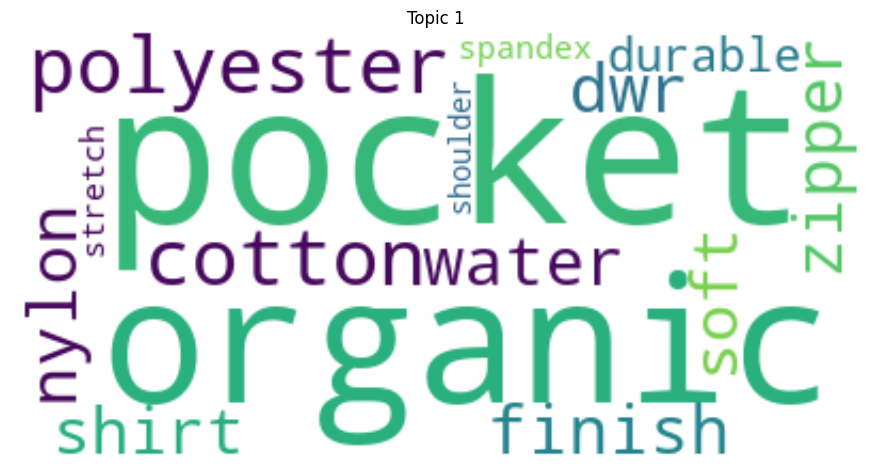

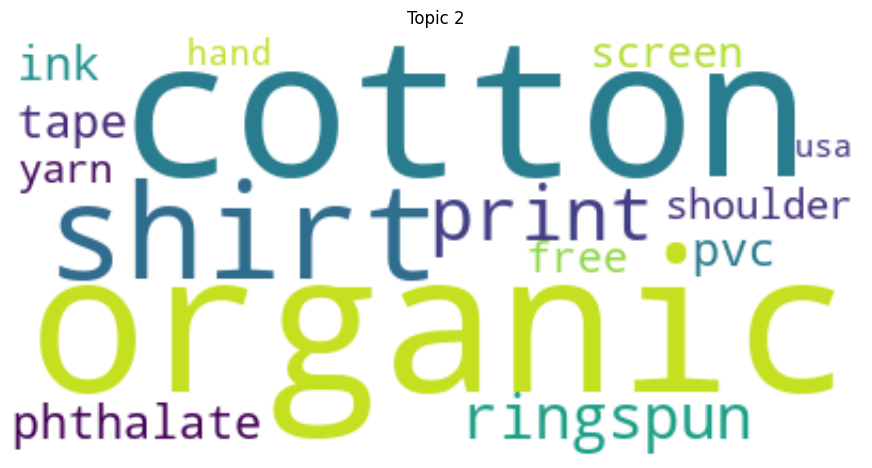

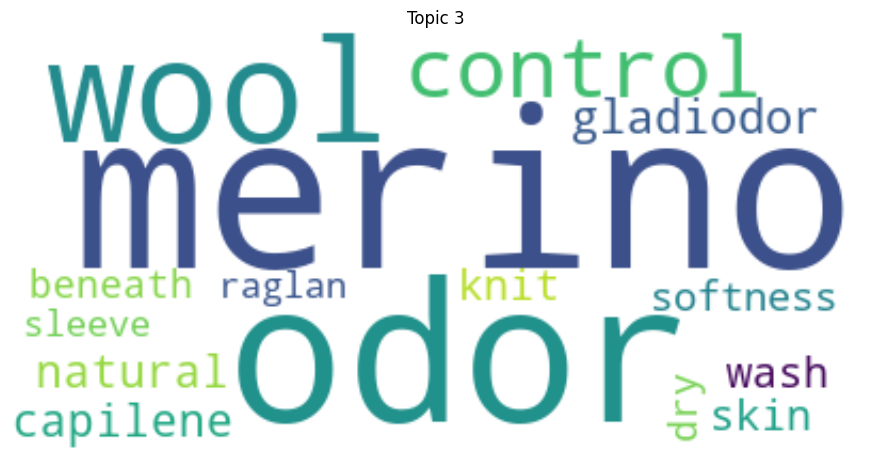

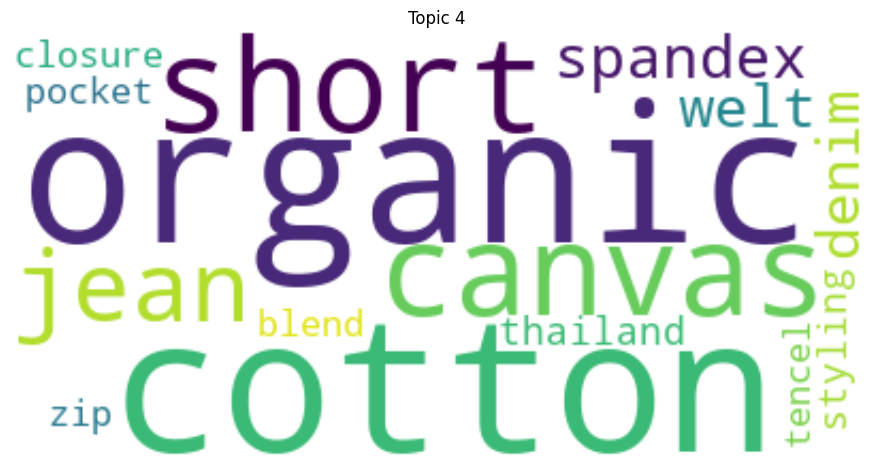

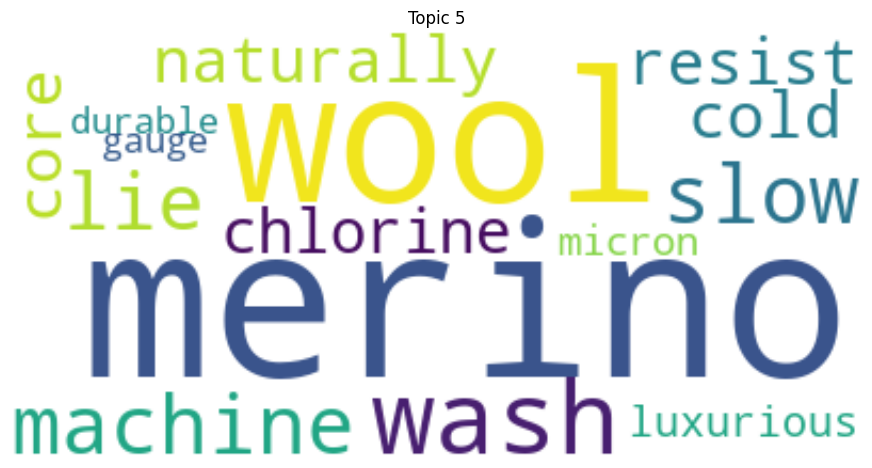

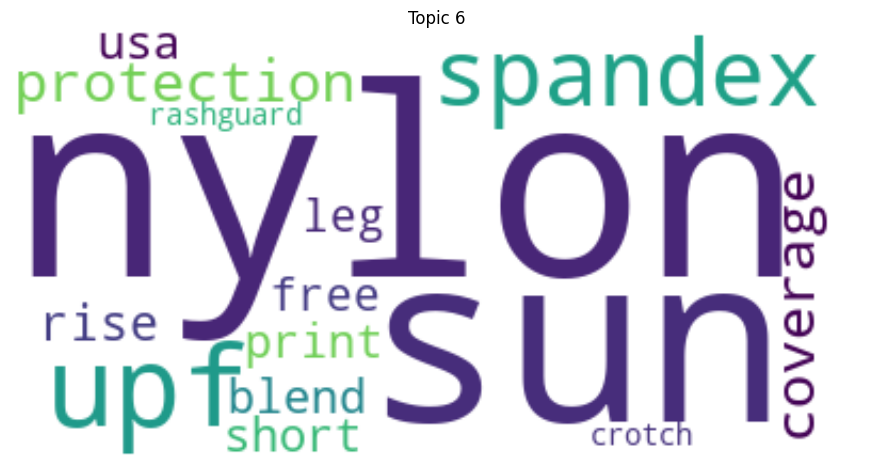

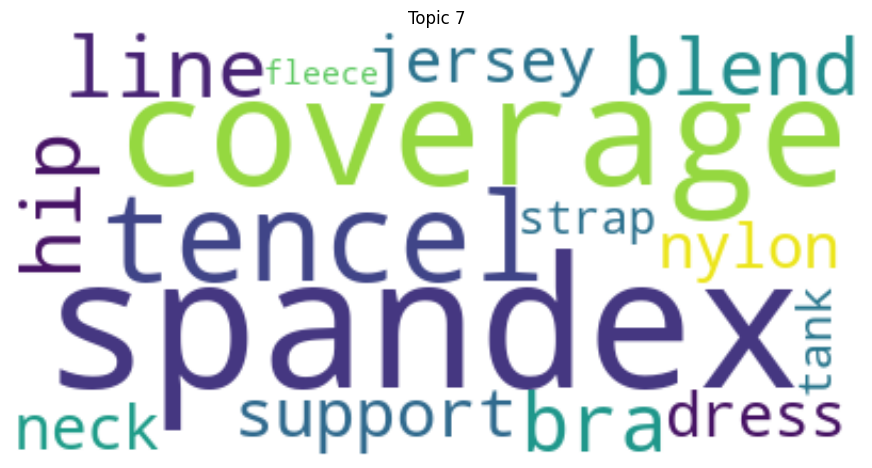

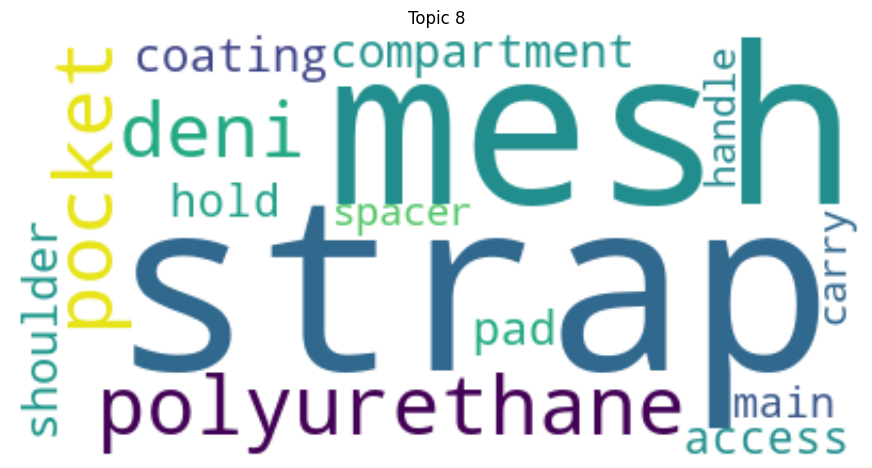

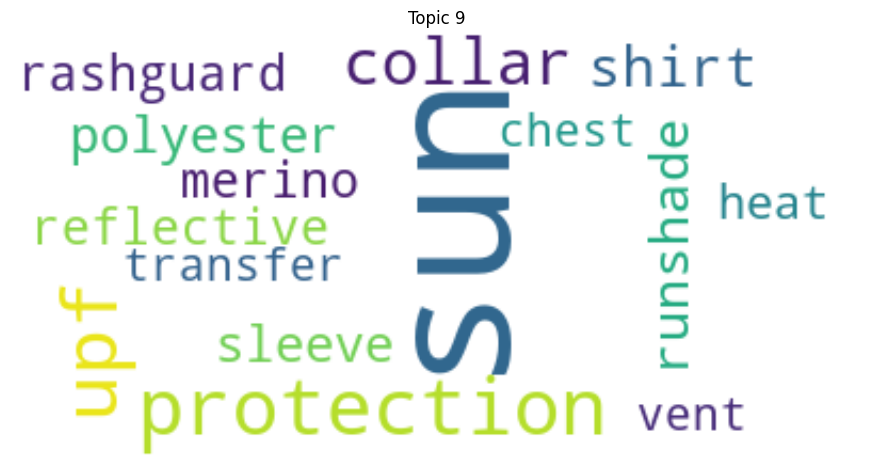

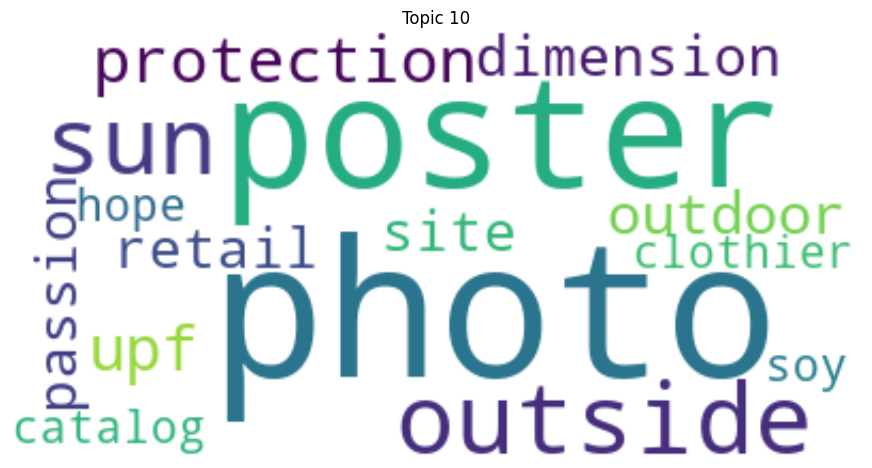

In [46]:
# Generate a wordcloud with the top 15 words, for each topic

n_top_words = 15

for i in range(svd_model.components_.shape[0]): 
    
    # retrieve the coefficients for each topic
    topic = svd_model.components_[i]
    
    # identify top indices
    top_indices = topic.argsort()[::-1][:n_top_words]
    
    # identify top words and their frequencies
    top_words = [vocabulary[i] for i in top_indices] 
    top_frequency = [topic[i] for i in top_indices] 
    
    # create a dictionary with top words and their frequencies
    dict_word_frequency = dict(zip(top_words, top_frequency))

    # generate wordcloud
    cloud = wd.generate_from_frequencies(frequencies=dict_word_frequency)
    plt.figure(figsize = (11, 9))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f'Topic {i + 1}') 
    plt.show()


In [47]:
for i in range(svd_model.components_.shape[0]): 
    
    # retrieve the coefficients for each topic
    topic = svd_model.components_[i]
    
    # identify top indices
    top_indices = topic.argsort()[::-1][:n_top_words]
    
    # identify top words and their frequencies
    top_words = [vocabulary[i] for i in top_indices] 
    top_frequency = [topic[i] for i in top_indices] 
    
    # display list of top words
    print(top_words)

['pocket', 'organic', 'polyester', 'cotton', 'water', 'dwr', 'nylon', 'zipper', 'finish', 'shirt', 'soft', 'durable', 'spandex', 'stretch', 'shoulder']
['organic', 'cotton', 'shirt', 'print', 'ringspun', 'phthalate', 'pvc', 'tape', 'ink', 'screen', 'free', 'shoulder', 'yarn', 'hand', 'usa']
['merino', 'odor', 'wool', 'control', 'gladiodor', 'natural', 'capilene', 'skin', 'wash', 'knit', 'softness', 'beneath', 'dry', 'raglan', 'sleeve']
['organic', 'cotton', 'short', 'canvas', 'jean', 'spandex', 'welt', 'denim', 'thailand', 'styling', 'closure', 'zip', 'tencel', 'pocket', 'blend']
['merino', 'wool', 'wash', 'machine', 'slow', 'lie', 'naturally', 'resist', 'core', 'cold', 'chlorine', 'luxurious', 'micron', 'durable', 'gauge']
['nylon', 'sun', 'upf', 'spandex', 'protection', 'coverage', 'rise', 'blend', 'short', 'usa', 'print', 'free', 'leg', 'rashguard', 'crotch']
['spandex', 'coverage', 'tencel', 'line', 'hip', 'bra', 'blend', 'support', 'jersey', 'nylon', 'dress', 'neck', 'strap', 'tan

Looking at the top words, we suggest the following topics:
- topic 1: materials and features of clothing
- topic 2: eco-friendliness clothing
- topic 3: merino wool clothing: focus on odor-resistant property
- topic 4: organic cotton jeans
- topic 5: merino wool clothing: focus on washing
- topic 6: lower body clothing with stretch and sun protection fabric
- topic 7: technical sportswear lingerie
- topic 8: accessories
- topic 9: upper body clothing with sun protection fabric
- topic 10: outdoor products